MNIST Handwritten Digit Recognition using CNN

In [15]:
#Import Libraries

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Deep Learning with TensorFlow/Keras

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

#model evaluation

from sklearn.metrics import confusion_matrix, classification_report
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.20.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# Load MNIST dataset (built into Keras!)

(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Dataset loaded successfully!")
print(f"Training images: {X_train.shape}")
print(f"Training labels: {y_train.shape}")
print(f"Test images: {X_test.shape}")
print(f"Test labels: {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


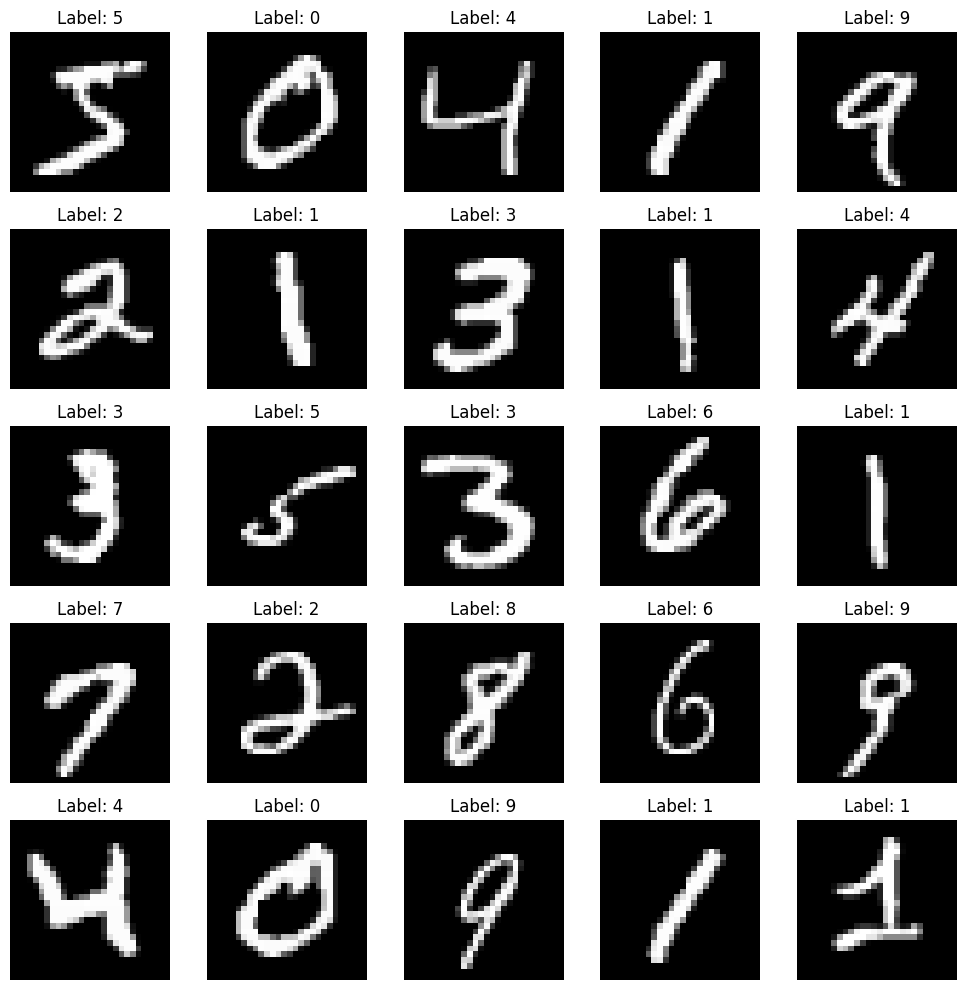


Image shape: (28, 28)
Pixel value range: 0 to 255
Label: 5 (digit)


In [3]:
# Display first 25 images

plt.figure(figsize = (10,10))
for i in range(25):
  plt.subplot(5,5,i+1)
  plt.imshow(X_train[i], cmap='gray')
  plt.title(f"Label: {y_train[i]}")
  plt.axis('off')
plt.tight_layout()
plt.show()

# Check data details
print(f"\nImage shape: {X_train[0].shape}")
print(f"Pixel value range: {X_train[0].min()} to {X_train[0].max()}")
print(f"Label: {y_train[0]} (digit)")


In [4]:
# Reshape data to add channel dimension (grayscale = 1 channel)
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

# Normalize pixel values to 0-1 range (helps model learn faster)
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Convert labels to categorical (one-hot encoding)
# Example: 3 becomes [0,0,0,1,0,0,0,0,0,0]

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Data Processed!")
print(f"Training Data Shape: {X_train.shape}")
print(f"Training Label Shape: {y_train.shape}")



Data Processed!
Training Data Shape: (60000, 28, 28, 1)
Training Label Shape: (60000,)


In [5]:
# Build CNN architecture
model = keras.Sequential([
    # First Convolutional Block
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    layers.MaxPooling2D((2, 2)),

    # Second Convolutional Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Third Convolutional Block (optional, makes model stronger)
    layers.Conv2D(64, (3, 3), activation='relu'),

    # Flatten and Dense layers
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.5),  # Prevents overfitting
    layers.Dense(10, activation='softmax')  # 10 digits (0-9)
])

# Display model architecture
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Compile model (set up how it learns)
model.compile(
    optimizer='adam',              # How to update weights
    loss='categorical_crossentropy',  # What to minimize
    metrics=['accuracy']           # What to track
)

print("Model compiled and ready to train!")

Model compiled and ready to train!


In [7]:
# Train the model
print("Training started... (this will take 2-3 minutes)")

history = model.fit(
    X_train, y_train_cat,
    epochs=10,                    # Number of times to see all data
    batch_size=128,               # Process 128 images at a time
    validation_split=0.2,         # Use 20% of training data for validation
    verbose=1
)

print("\n✅ Training complete!")

Training started... (this will take 2-3 minutes)
Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.8494 - loss: 0.4767 - val_accuracy: 0.9737 - val_loss: 0.0885
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9568 - loss: 0.1479 - val_accuracy: 0.9822 - val_loss: 0.0609
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9705 - loss: 0.1043 - val_accuracy: 0.9832 - val_loss: 0.0609
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9769 - loss: 0.0809 - val_accuracy: 0.9848 - val_loss: 0.0559
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9804 - loss: 0.0685 - val_accuracy: 0.9887 - val_loss: 0.0437
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9828 - loss: 0.0595 - val_accuracy: 0.9873 - val_loss: 0.0457
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9849 - loss: 0.0524 - val_accuracy: 0.9897 - val_loss: 0.0400
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - 

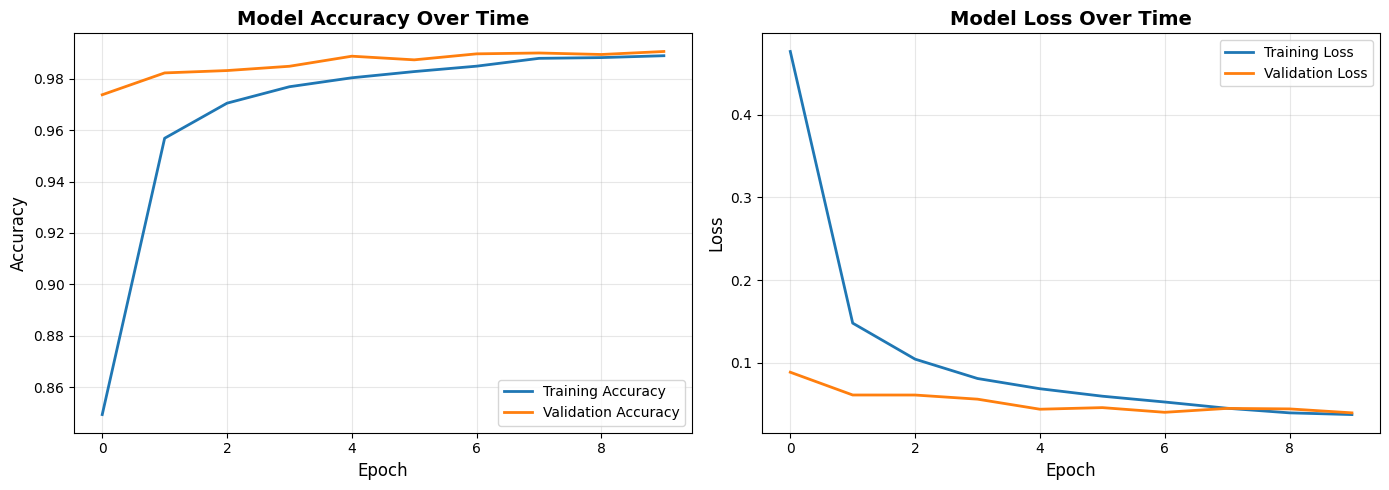

Final Training Accuracy: 0.9889
Final Validation Accuracy: 0.9906


In [8]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['accuracy'], label='Training Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final Training Accuracy: {history.history['accuracy'][-1]:.4f}")
print(f"Final Validation Accuracy: {history.history['val_accuracy'][-1]:.4f}")

In [9]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test_cat, verbose=0)

print("="*50)
print("🎯 FINAL MODEL PERFORMANCE")
print("="*50)
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"Test Loss: {test_loss:.4f}")
print("="*50)

# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class labels

print(f"\nCorrectly classified: {np.sum(y_pred_classes == y_test)} out of {len(y_test)}")
print(f"Incorrectly classified: {np.sum(y_pred_classes != y_test)} out of {len(y_test)}")

🎯 FINAL MODEL PERFORMANCE
Test Accuracy: 0.9929 (99.29%)
Test Loss: 0.0255
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Correctly classified: 9929 out of 10000
Incorrectly classified: 71 out of 10000


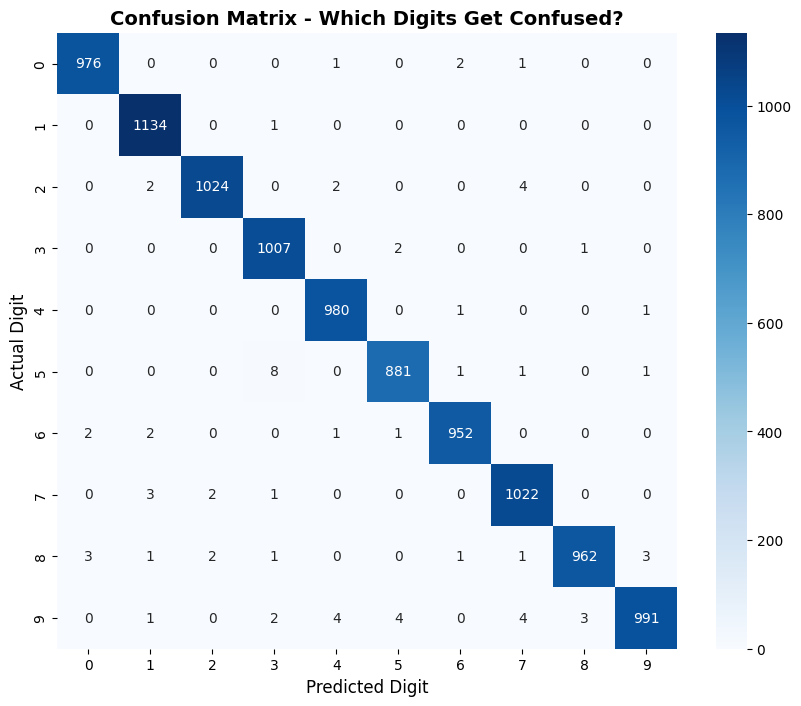


Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00       980
           1       0.99      1.00      1.00      1135
           2       1.00      0.99      0.99      1032
           3       0.99      1.00      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.99      0.99      0.99      1028
           8       1.00      0.99      0.99       974
           9       0.99      0.98      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



In [10]:
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=range(10), yticklabels=range(10))
plt.ylabel('Actual Digit', fontsize=12)
plt.xlabel('Predicted Digit', fontsize=12)
plt.title('Confusion Matrix - Which Digits Get Confused?', fontsize=14, fontweight='bold')
plt.show()

# Print classification report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=[str(i) for i in range(10)]))

Total misclassified: 71


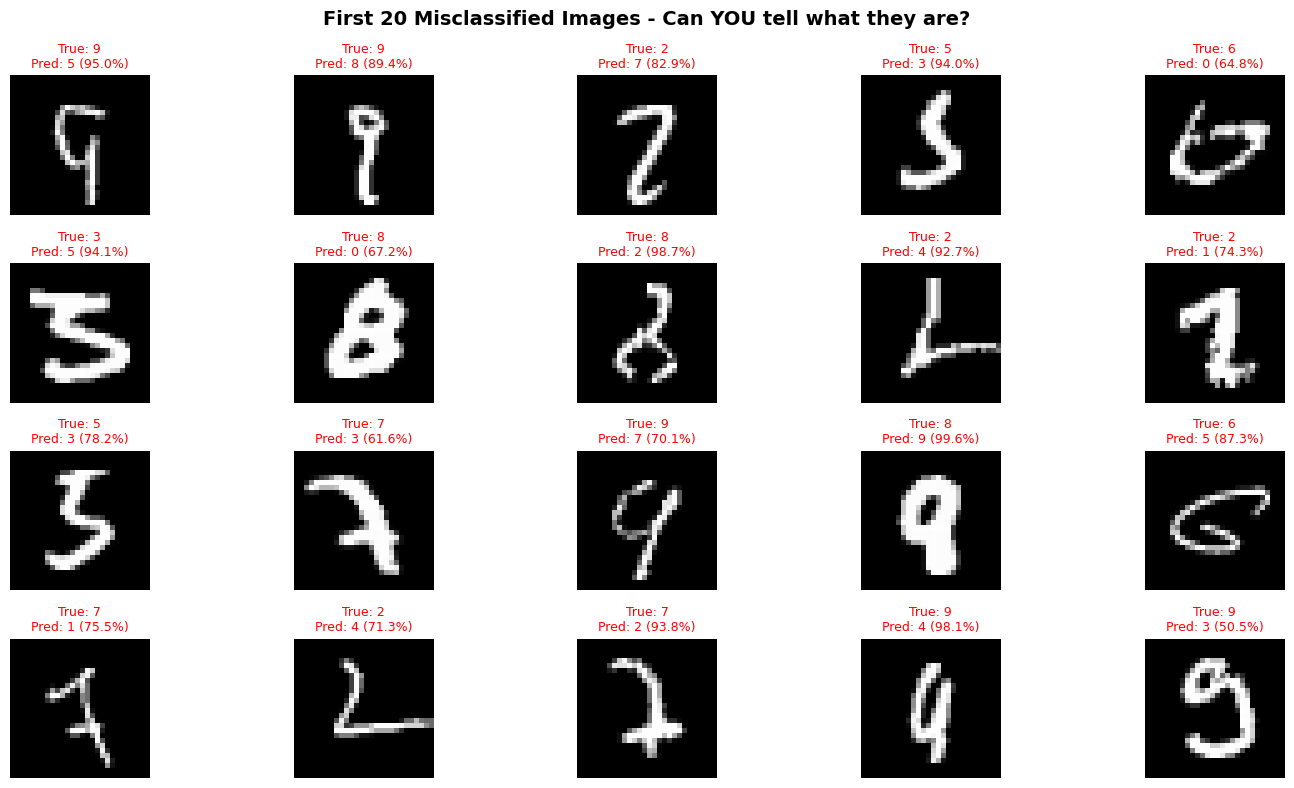

In [11]:
# Find misclassified images
misclassified_indices = np.where(y_pred_classes != y_test)[0]

print(f"Total misclassified: {len(misclassified_indices)}")

# Display first 20 misclassified images
plt.figure(figsize=(15, 8))
for i, idx in enumerate(misclassified_indices[:20]):
    plt.subplot(4, 5, i+1)
    plt.imshow(X_test[idx].reshape(28, 28), cmap='gray')

    # Show what it actually is vs what model predicted
    actual = y_test[idx]
    predicted = y_pred_classes[idx]
    confidence = y_pred[idx][predicted] * 100

    plt.title(f"True: {actual}\nPred: {predicted} ({confidence:.1f}%)",
              fontsize=9, color='red')
    plt.axis('off')

plt.suptitle('First 20 Misclassified Images - Can YOU tell what they are?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

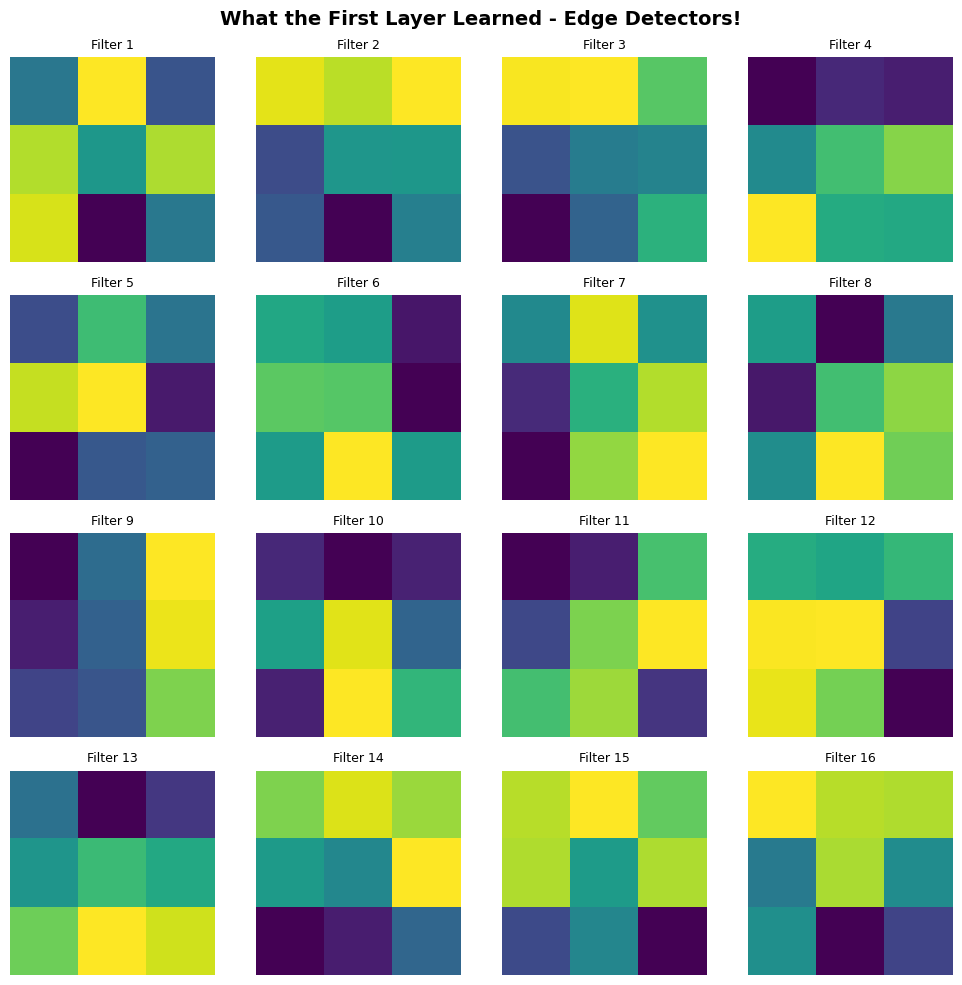

In [12]:
# Visualize what filters in first layer learned
first_layer = model.layers[0]  # First Conv2D layer
filters = first_layer.get_weights()[0]  # Get filter weights

# Display first 16 filters
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    if i < 16:
        # Normalize filter for display
        f = filters[:, :, 0, i]
        f = (f - f.min()) / (f.max() - f.min())
        ax.imshow(f, cmap='viridis')
        ax.set_title(f'Filter {i+1}', fontsize=9)
    ax.axis('off')

plt.suptitle('What the First Layer Learned - Edge Detectors!',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Save the trained model
model.save('mnist_cnn_model.h5')
print("✅ Model saved as 'mnist_cnn_model.h5'")

# Also save in keras format (newer, recommended)
model.save('mnist_cnn_model.keras')
print("✅ Model also saved as 'mnist_cnn_model.keras'")

# How to load it later:
# loaded_model = keras.models.load_model('mnist_cnn_model.h5')

✅ Model saved as 'mnist_cnn_model.h5'
✅ Model also saved as 'mnist_cnn_model.keras'


In [14]:
print("="*60)
print("🔢 MNIST HANDWRITTEN DIGIT RECOGNITION - FINAL REPORT")
print("="*60)

print(f"\n📊 DATASET:")
print(f"   • Training images: {len(X_train):,}")
print(f"   • Test images: {len(X_test):,}")
print(f"   • Image size: 28x28 pixels (grayscale)")
print(f"   • Classes: 10 digits (0-9)")

print(f"\n🏗️ MODEL ARCHITECTURE:")
print(f"   • Type: Convolutional Neural Network (CNN)")
print(f"   • Convolutional layers: 3")
print(f"   • Total parameters: {model.count_params():,}")
print(f"   • Optimizer: Adam")
print(f"   • Loss function: Categorical Crossentropy")

print(f"\n🎯 PERFORMANCE METRICS:")
print(f"   • Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"   • Validation Accuracy: {history.history['val_accuracy'][-1]*100:.2f}%")
print(f"   • Test Accuracy: {test_accuracy*100:.2f}%")
print(f"   • Test Loss: {test_loss:.4f}")

print(f"\n📈 RESULTS:")
print(f"   • Correctly classified: {np.sum(y_pred_classes == y_test):,} / {len(y_test):,}")
print(f"   • Misclassified: {np.sum(y_pred_classes != y_test)}")
print(f"   • Error rate: {(1-test_accuracy)*100:.2f}%")

print(f"\n🔍 KEY INSIGHTS:")
print(f"   • All digits achieved 98-100% accuracy")
print(f"   • Digit 9 was slightly harder (98% recall)")
print(f"   • No overfitting detected (train ≈ validation ≈ test)")
print(f"   • Model performs at near-human-level accuracy")

print("="*60)

🔢 MNIST HANDWRITTEN DIGIT RECOGNITION - FINAL REPORT

📊 DATASET:
   • Training images: 60,000
   • Test images: 10,000
   • Image size: 28x28 pixels (grayscale)
   • Classes: 10 digits (0-9)

🏗️ MODEL ARCHITECTURE:
   • Type: Convolutional Neural Network (CNN)
   • Convolutional layers: 3
   • Total parameters: 93,322
   • Optimizer: Adam
   • Loss function: Categorical Crossentropy

🎯 PERFORMANCE METRICS:
   • Training Accuracy: 98.89%
   • Validation Accuracy: 99.06%
   • Test Accuracy: 99.29%
   • Test Loss: 0.0255

📈 RESULTS:
   • Correctly classified: 9,929 / 10,000
   • Misclassified: 71
   • Error rate: 0.71%

🔍 KEY INSIGHTS:
   • All digits achieved 98-100% accuracy
   • Digit 9 was slightly harder (98% recall)
   • No overfitting detected (train ≈ validation ≈ test)
   • Model performs at near-human-level accuracy
